In [1]:
# Основные библиотеки
import numpy as np
import pandas as pd
import os
import pyarrow.parquet as pq

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Разбиение данных на тренировочные и тестовые
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.decomposition import PCA

# Алгоритмы
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Метрики$
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def precision( y, y_pred, y_proba, shold, label ):
    ind_f = ( y==label ) & ( y_pred!=label ) & ( y_proba[:,label]<shold )   # errors     
    ind_p = ( y_pred==label ) & ( y==label ) & ( y_proba[:,label]>=shold )  # rights
    return( y[ind_p].shape[0]/(y[ind_p].shape[0] + y[ind_f].shape[0] ) )

def recall( y, y_pred, y_proba, shold, label1, label2 ):
    ind_f = ( y==label2 ) & ( y_pred!=label2 )# & ( y_proba[:,label1]<shold )   # errors FN    
    ind_p = ( y_pred==label1 ) & ( y==label1 ) # & ( y_proba[:,label]>=shold )  # rights  TP
    return( y[ind_p].shape[0]/(y[ind_p].shape[0] + y[ind_f].shape[0] ) )

def accuracy (y, y_pred, y_proba, shold, label_pos, label_neg):
    accuracy = np.where( y==y_pred )[0].shape[0]/y.shape[0]
    return ( accuracy )
    
def f1_score (y, y_pred, y_proba, shold, label_pos, label_neg):
    p = precision(y, y_pred, y_proba, shold, label_pos)
    r = recall(y, y_pred, y_proba, shold, label_pos, label_neg)
    return 2 * ( ( p * r )/( p + r ) )

import pickle

path_current = os.getcwd()
path_ch2_graphics = os.path.join(os.getcwd(),'ch2/graphics')
path_ch3_graphics = os.path.join(os.getcwd(),'ch3/graphics')

def jpeg( fig, file_, folder ):
    from PIL import Image
    format_ = 'png'    
    data_folder = path_current
    d = os.path.join( data_folder  )
    os.chdir( d )
    check_file = os.path.exists( folder )
    if check_file == False:           
        os.chdir(os.path.join( data_folder ))
        os.mkdir( folder )
    f = os.path.join( data_folder, folder ) 
    os.chdir( f )
    fig.savefig( file_, format = format_ )
    im = Image.open(  file_ )
    rgb_im = im.convert('RGB')
    rgb_im.save(  file_ +   '.png' )
    os.remove( os.path.join( f, file_ ) )

In [2]:
os.getcwd() 
os.path.join(os.getcwd(), 'ch2/graphics')

'/Users/macbookpro/Desktop/Диплом/python/ch2/graphics'

In [ ]:
# path_ch2_graphics = '/Users/macbookpro/Desktop/Диплом/tex_dak/ch2/graphics/matrix_dtr_train_test_3mln_random.png'

# Глава 2. Предобработка данных, стр.14


In [ ]:
path = "train_data"                             
for i,file in enumerate(os.listdir(path)):
    print('train_data_' + str(i) + '.pq')
    file = 'train_data_' + str(i) + '.pq'
    dataset = pq.ParquetDataset(os.path.join(path,file))
    df = dataset.read(use_threads=True).to_pandas()
    df_gr = df.groupby('id').agg('mean')
    file_csv = file.replace('.pq', '.csv')
    df_gr.to_csv(os.path.join('train_data_csv_all',file_csv))
#os.listdir(path)

In [8]:
path = 'train_data_csv_all'  
frames = []
for i,file_csv in enumerate(os.listdir(path)):
    file_csv = 'train_data_' + str(i) + '.csv'
    print(file_csv)
    df = pd.read_csv(os.path.join('train_data_csv_all',file_csv))
    frames.append(df)

train_data_0.csv
train_data_1.csv
train_data_2.csv
train_data_3.csv
train_data_4.csv
train_data_5.csv
train_data_6.csv
train_data_7.csv
train_data_8.csv
train_data_9.csv
train_data_10.csv
train_data_11.csv


In [9]:
result = pd.concat(frames)

In [ ]:
file_csv_all = '1_data_csv_all_general.csv' 
result.to_csv(file_csv_all)

# Загрузка всех данных

In [3]:
file_csv_all = '1_data_csv_all_general.csv' # Загрузка всех данных
df = pd.read_csv(file_csv_all)
columns = ['pre_pterm', 'pre_fterm', 'pre_loans_next_pay_summ',
           'pre_loans_outstanding', 'pre_loans_total_overdue',
           'pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate',
           'is_zero_loans5', 'is_zero_loans530', 'is_zero_loans3060',
           'is_zero_loans6090', 'is_zero_loans90', 'pre_util',
           'pre_maxover2limit', 'is_zero_util', 'is_zero_over2limit',
           'enc_paym_0', 'enc_paym_1', 'enc_paym_2',
           'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 
           'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 
           'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 
           'enc_paym_12', 'enc_paym_13', 'enc_paym_14', 
           'enc_paym_15', 'enc_paym_16', 'enc_paym_17', 
           'enc_paym_18', 'enc_paym_19', 'enc_paym_20',
           'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24'] # 41 признак
X_pay = df.loc[:1000000, columns].copy()                               # Дисциплинарная матрица 1

In [4]:
df_y = pd.read_csv('train_target.csv')
y  = df_y.flag.values[:1000001] # Глава 2. 1 млн клиентов до аномальности
y_ = df_y.flag.values[:1000001] # Глава 2. 1 млн клиентов после аномальности

# Тестирование на алгоритме Random Forest (41 признак, стр. 17)

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X_pay, y, test_size=0.25, random_state=0)
rfc = RandomForestClassifier( )
rfc.fit( X_train, Y_train )
rfc.score( X_train, Y_train ), rfc.score( X_test, Y_test)

(0.9980906666666667, 0.9656081375674497)

In [6]:
y_pred_train = rfc.predict( X_train )
y_pred_test = rfc.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    724650
           1       1.00      0.95      0.97     25350

    accuracy                           1.00    750000
   macro avg       1.00      0.97      0.99    750000
weighted avg       1.00      1.00      1.00    750000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    241508
           1       0.24      0.01      0.01      8493

    accuracy                           0.97    250001
   macro avg       0.60      0.50      0.50    250001
weighted avg       0.94      0.97      0.95    250001



# Метрика ROC-AUC

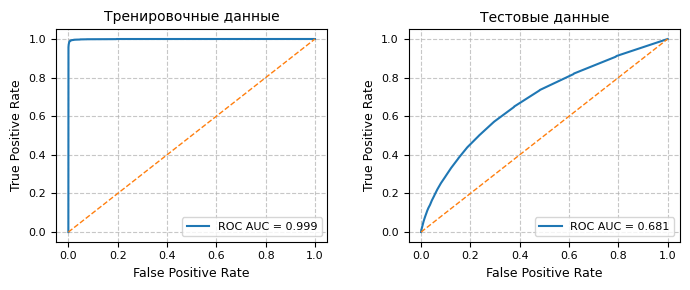

In [7]:
y_score_train = rfc.predict_proba(X_train)[:, 1]   
y_score_test = rfc.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
# plt.savefig(   '1' )

# Глава 2. Метод главных компонент(41 признак, стр. 18)

In [8]:
pca = PCA()  
pca.fit(X_pay)  
100*pca.explained_variance_ratio_.round(3)

array([22.3, 20.3, 17.6, 10.8,  9.5,  7.6,  4.2,  1.7,  1.5,  0.8,  0.6,
        0.5,  0.4,  0.3,  0.3,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ])

# Глава 2. Метод главных компонент(25 признаков, стр. 19)

In [3]:
file_csv_all_25 = '2_data_csv_all_25.csv' # Загрузка данных только с 25 признаками с целью сохранения оперативной памяти
df_all_25 = pd.read_csv(file_csv_all_25)
columns_pay_25 = ['enc_paym_0', 'enc_paym_1', 'enc_paym_2',
                  'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 
                  'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 
                  'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 
                  'enc_paym_12', 'enc_paym_13', 'enc_paym_14', 
                  'enc_paym_15', 'enc_paym_16', 'enc_paym_17', 
                  'enc_paym_18', 'enc_paym_19', 'enc_paym_20',
                  'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24'] # 25 признаков
X_pay_25 = df_all_25.loc[:1000000, columns_pay_25].copy()  

In [5]:
pca = PCA()  
pca.fit(X_pay_25)  
100*pca.explained_variance_ratio_.round(3)

array([66.3, 15.6,  5.5,  2.9,  1.8,  1.3,  1. ,  0.8,  0.7,  0.6,  0.5,
        0.4,  0.4,  0.3,  0.3,  0.3,  0.3,  0.2,  0.2,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1])

In [5]:
y[y==1].shape[0]

33843

# Глава 2. Определение аномального клиента,  стр. 19-23

# График до выявления аномальности стр. 20

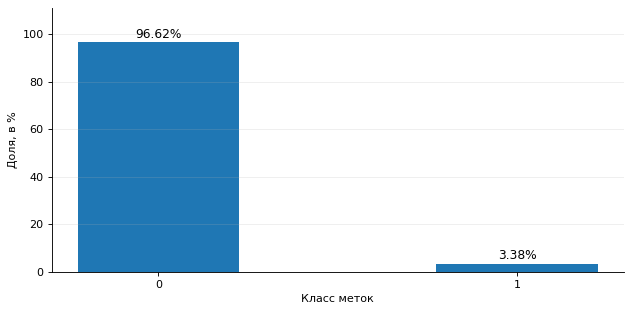

In [6]:
y_arr = np.asarray(y)
x = np.array([0, 1])

anoms = np.array([100*y_arr[y_arr==0].shape[0]/y_arr.shape[0], 
                  100*y_arr[y_arr==1].shape[0]/y_arr.shape[0]])

fig, ax = plt.subplots(nrows = 1, 
                            ncols = 1,
                            dpi = 80,
                            figsize = (8, 4))

bars = ax.bar(x, anoms, width=0.45)

for xi, p in zip(x, anoms):
    ax.text(xi, p + 0.6, f'{p:.2f}%', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Доля, в %')
ax.set_xlabel('Класс меток')
ax.set_xticks(x)
ax.set_xticklabels(['0', '1'])
ax.set_ylim(0, max(anoms)*1.15)
ax.grid(axis='y', linewidth=0.6, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
jpeg(fig, 'labels_before_anom', path_ch2_graphics)

In [25]:
np.array(X_pay_25)

array([[0.1       , 0.        , 0.6       , ..., 2.4       , 2.4       ,
        4.        ],
       [0.28571429, 0.78571429, 0.71428571, ..., 2.42857143, 2.35714286,
        3.35714286],
       [1.        , 1.        , 1.        , ..., 2.33333333, 2.33333333,
        4.        ],
       ...,
       [0.        , 0.33333333, 0.5       , ..., 1.83333333, 1.83333333,
        3.        ],
       [0.        , 0.        , 0.        , ..., 1.5       , 1.5       ,
        2.5       ],
       [0.4       , 1.        , 1.        , ..., 2.4       , 2.4       ,
        3.4       ]])

# Выявление аномальных клиентов (0 --> 1). Глава 2. 1 млн клиентов, стр. 20

In [7]:
counter_norm, counter_anom = 0, 0
ind_norm, ind_anom = [], []
for i,x_pay in enumerate(np.array(X_pay_25)):
    if y_[i]==0 and min(x_pay)>0:
        counter_anom +=1
        ind_anom.append( i )
        y_[i]=1
    else:
        counter_norm +=1
        ind_norm.append( i )
print(f'amount of anomal customer={counter_anom}')
print(f'amount of normal customer={counter_norm}') 

amount of anomal customer=340594
amount of normal customer=659407


In [2]:
(340594/966158)*100

35.25241213134912

In [21]:
y[y==0].shape[0]/y.shape[0]

0.6255633744366256

# График после выявления аномальности, стр. 21

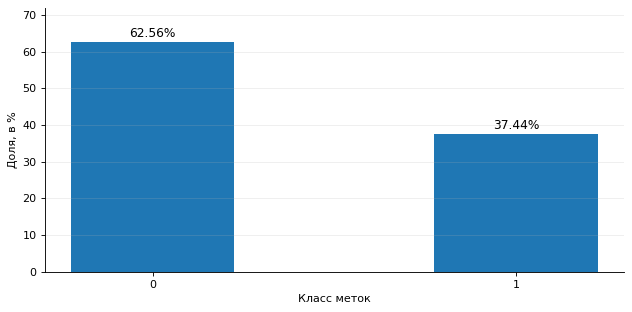

In [8]:
y_new_arr = np.asarray(y_) 
x = np.array([0, 1])
anoms_new = np.array([100*y_new_arr[y_new_arr==0].shape[0]/y_new_arr.shape[0], 
                      100*y_new_arr[y_new_arr==1].shape[0]/y_new_arr.shape[0]])
fig, ax = plt.subplots(nrows=1,
                       ncols=1,
                       dpi=80,
                       figsize=(8, 4))
bars = ax.bar(x, anoms_new, width=0.45)
for xi, p in zip(x, anoms_new):
    ax.text(xi, p + 0.6, f'{p:.2f}%', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Доля, в %')
ax.set_xlabel('Класс меток')
ax.set_xticks(x)
ax.set_xticklabels(['0', '1'])
ax.set_ylim(0, max(anoms_new) * 1.15)
ax.grid(axis='y', linewidth=0.6, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
jpeg(fig, 'labels_after_anom', path_ch2_graphics)

# Результат переклассификации меток клиентов, стр. 22

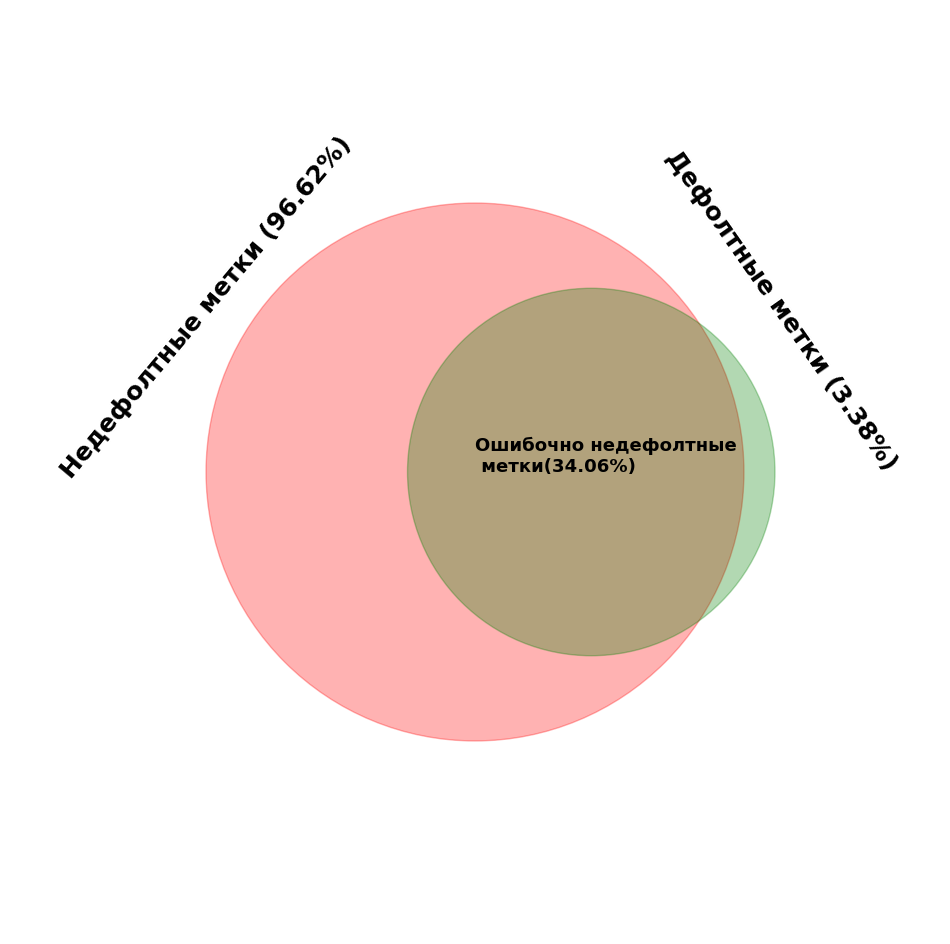

In [3]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1)
plt.scatter(x=[0, 0.25], y=[0,0], s=[150000, 70000], color=['red', 'green'], alpha=0.3)
plt.text(x=-0.9, y=-0.0007, s='Недефолтные метки (96.62%)', rotation=50, fontsize=18, fontweight='bold', color='black')
plt.text(x=0.4, y=0.0003, s='Дефолтные метки (3.38%)', rotation=-55, fontsize=18, fontweight='bold', color='black')
plt.text(x=0.00005, y=0.00001, s='Ошибочно недефолтные\n метки(34.06%)', fontsize=13, fontweight='bold')
plt.xlim(-1, 1)
ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
ax.yaxis.set_visible(False)
ax.xaxis.set_visible(False)
jpeg(fig, 'Euler', path_ch2_graphics)

# Реакция алгоритма случайного леса на 25 признаках после PCA, стр. 22

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X_pay_25, y_, test_size=0.25, random_state=0)
rfc = RandomForestClassifier( )
rfc.fit( X_train, Y_train )
rfc.score( X_train, Y_train ), rfc.score( X_test, Y_test)

(0.9932773333333333, 0.9809840760636958)

In [8]:
y_pred_train = rfc.predict( X_train )
y_pred_test = rfc.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    469239
           1       1.00      0.98      0.99    280761

    accuracy                           0.99    750000
   macro avg       0.99      0.99      0.99    750000
weighted avg       0.99      0.99      0.99    750000

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    156325
           1       1.00      0.95      0.97     93676

    accuracy                           0.98    250001
   macro avg       0.98      0.97      0.98    250001
weighted avg       0.98      0.98      0.98    250001



# Метрика ROC-AUC

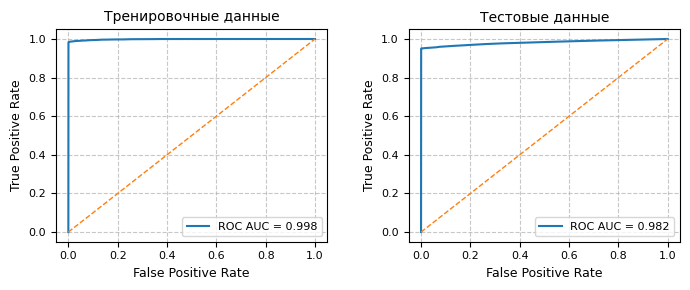

In [9]:
y_score_train = rfc.predict_proba(X_train)[:, 1]   
y_score_test = rfc.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

# Статистический тест Колмогорова-Смирнова, стр. 23-28

In [14]:
col = 'enc_paym_15'
T = X_pay_25.enc_paym_15        
x00, x01, x11 = T[(y==0) & (y_== 0)], T[ind_anom], T[(y==1)]  # 0(0) и 1(0) H_1 и 1(1)
ind00 = (x00!=0) & (x00!=1) & (x00!=2) & (x00!=3) & (x00!=4) & (x00!=5)
ind01 = (x01!=0) & (x01!=1) & (x01!=2) & (x01!=3) & (x01!=4) & (x01!=5)
ind11 = (x11!=0) & (x11!=1) & (x11!=2) & (x11!=3) & (x11!=4) & (x11!=5)
x00, x11, x01 = x00[ind00], x11[ind11], x01[ind01]

In [15]:
def my_cdf(x1, x2, step): 
    tm = max( max(x1), max(x2) )
    F1,F2 = [], []
    n1, n2 = x1[x1>=0].shape[0], x2[x2>=0].shape[0]
    for t in np.arange(0, tm+0.1, step):
        F1.append( x1[(x1>0)&(x1<t)].shape[0] )
        F2.append( x2[(x2>0)&(x2<t)].shape[0] )
    F1, F2 = np.array(F1)/n1, np.array(F2)/n2
    K = max(abs(F1-F2))*np.sqrt( n1*n2/(n1+n2) )
    return F1, F2, K, tm
step = 0.01
F01,  F11, K,  tm = my_cdf( x01, x11, step )
F01_, F00, K_, tm = my_cdf( x01, x00, step )
# print('corr = ',np.corrcoef(F01, F11)[0,1],  len(F01))
# print('corr = ',np.corrcoef(F01_,F00)[0,1], len(F01_))
r11, n11 = np.corrcoef(F01,  F11)[0,1], len(F11)
r00, n00 = np.corrcoef(F01_, F00)[0,1], len(F00)
K, K_

(1.3064382217840138, 68.86615937233813)

# Сравнение выборок аномальных (0->1) и дефолтных (1->1) клиентов, стр. 25

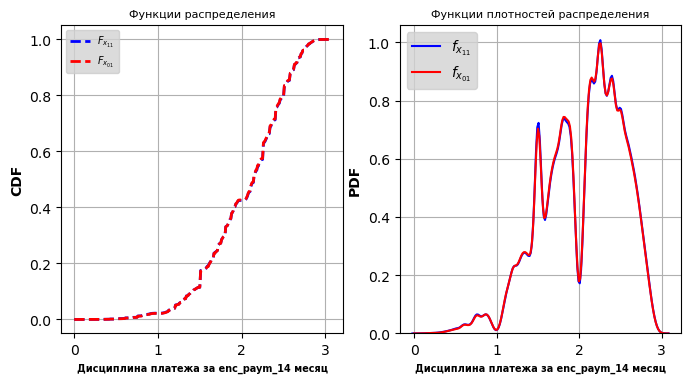

In [12]:
fig, (ax1,ax2) = plt.subplots( nrows = 1, 
                               ncols = 2,
                               dpi = 100,
                               figsize = ( 8, 4 )
                             )
ax1.plot( np.arange(0, tm+0.1, step),F11, linestyle='dashed', linewidth=2, color = 'blue', label = '$F_{x_{11}}$' )
ax1.plot( np.arange(0, tm+0.1, step),F01, linestyle='dashed', linewidth=2, color = 'red',  label = '$F_{x_{01}}$' )
ax1.set_xlabel( f'Дисциплина платежа за {col} месяц',   fontsize = '7', fontdict=dict(weight='bold') )
ax1.set_ylabel( 'CDF', fontsize = '10', fontdict=dict(weight='bold') )
ax1.legend( loc = 'upper left', facecolor = 'lightgrey', fontsize = '7' )
ax1.grid()
ax1.set_title('Функции распределения', fontsize = 8 )
sns.kdeplot(np.array(x11), ax = ax2, color = 'blue', label = '$f_{x_{11}}$') # 1
sns.kdeplot(np.array(x01), ax = ax2, color = 'red',  label = '$f_{x_{01}}$') # 1(0)
ax2.set_xlabel( f'Дисциплина платежа за {col} месяц',   fontsize = '7', fontdict=dict(weight='bold') )
ax2.set_ylabel( 'PDF', fontsize = '10', fontdict = dict(weight='bold') )
ax2.legend( loc = 'upper left', facecolor = 'lightgrey', fontsize = '10' )
ax2.grid()
ax2.set_title('Функции плотностей распределения', fontsize = 8 )
jpeg(fig, 'enc_paym_14_def', path_ch2_graphics)

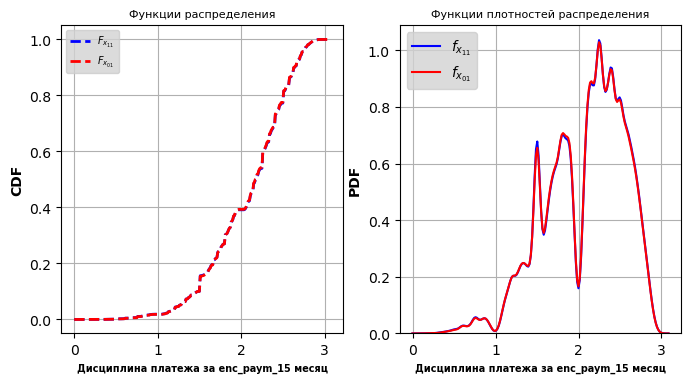

In [16]:
fig, (ax1,ax2) = plt.subplots( nrows = 1, 
                               ncols = 2,
                               dpi = 100,
                               figsize = ( 8, 4 )
                             )
ax1.plot( np.arange(0, tm+0.1, step),F11, linestyle='dashed', linewidth=2, color = 'blue', label = '$F_{x_{11}}$' )
ax1.plot( np.arange(0, tm+0.1, step),F01, linestyle='dashed', linewidth=2, color = 'red',  label = '$F_{x_{01}}$' )
ax1.set_xlabel( f'Дисциплина платежа за {col} месяц',   fontsize = '7', fontdict=dict(weight='bold') )
ax1.set_ylabel( 'CDF', fontsize = '10', fontdict=dict(weight='bold') )
ax1.legend( loc = 'upper left', facecolor = 'lightgrey', fontsize = '7' )
ax1.grid()
ax1.set_title('Функции распределения', fontsize = 8 )
sns.kdeplot(np.array(x11), ax = ax2, color = 'blue', label = '$f_{x_{11}}$') # 1
sns.kdeplot(np.array(x01), ax = ax2, color = 'red',  label = '$f_{x_{01}}$') # 1(0)
ax2.set_xlabel( f'Дисциплина платежа за {col} месяц',   fontsize = '7', fontdict=dict(weight='bold') )
ax2.set_ylabel( 'PDF', fontsize = '10', fontdict = dict(weight='bold') )
ax2.legend( loc = 'upper left', facecolor = 'lightgrey', fontsize = '10' )
ax2.grid()
ax2.set_title('Функции плотностей распределения', fontsize = 8 )
jpeg(fig, 'enc_paym_15_def', path_ch2_graphics)

# Сравнение выборок аномальных (0->1) и недефолтных (0->0) клиентов, стр. 26

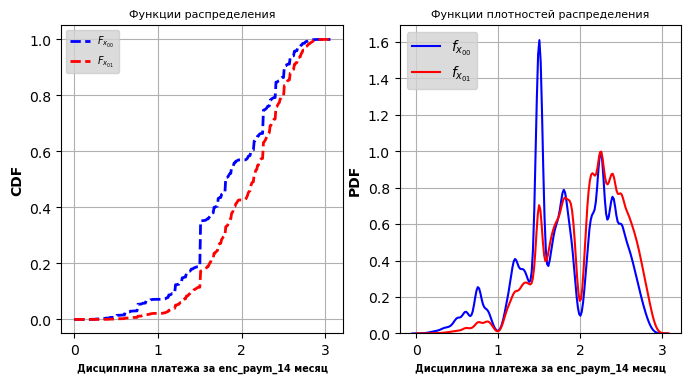

In [13]:
fig, (ax1,ax2) = plt.subplots( nrows = 1, 
                               ncols = 2,
                               dpi = 100,
                               figsize = ( 8, 4 )
                             )
ax1.plot( np.arange(0, tm+0.1, step),F00, linestyle='dashed', linewidth=2, color = 'blue', label = '$F_{x_{00}}$' )
ax1.plot( np.arange(0, tm+0.1, step),F01, linestyle='dashed', linewidth=2, color = 'red',  label = '$F_{x_{01}}$' )
ax1.set_xlabel( f'Дисциплина платежа за {col} месяц',   fontsize = '7', fontdict=dict(weight='bold') )
ax1.set_ylabel( 'CDF', fontsize = '10', fontdict=dict(weight='bold') )
ax1.legend( loc = 'upper left', facecolor = 'lightgrey', fontsize = '7' )
ax1.grid()
ax1.set_title('Функции распределения', fontsize = 8 )
sns.kdeplot(np.array(x00), ax = ax2, color = 'blue', label = '$f_{x_{00}}$') # 1
sns.kdeplot(np.array(x01), ax = ax2, color = 'red',  label = '$f_{x_{01}}$') # 1(0)
ax2.set_xlabel( f'Дисциплина платежа за {col} месяц',   fontsize = '7', fontdict=dict(weight='bold') )
ax2.set_ylabel( 'PDF', fontsize = '10', fontdict = dict(weight='bold') )
ax2.legend( loc = 'upper left', facecolor = 'lightgrey', fontsize = '10' )
ax2.grid()
ax2.set_title('Функции плотностей распределения', fontsize = 8 )
jpeg(fig, 'enc_paym_14_nodef', path_ch2_graphics)

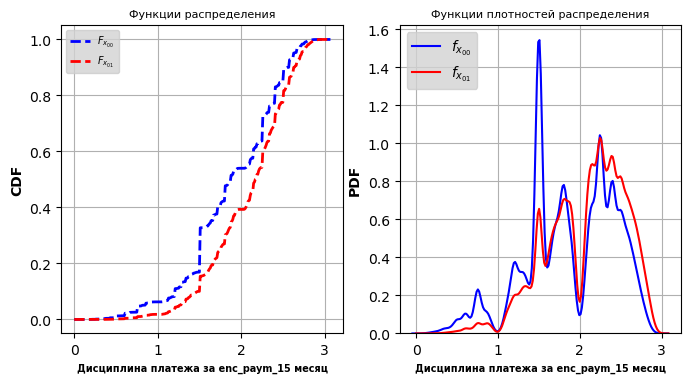

In [17]:
fig, (ax1,ax2) = plt.subplots( nrows = 1, 
                               ncols = 2,
                               dpi = 100,
                               figsize = ( 8, 4 )
                             )
ax1.plot( np.arange(0, tm+0.1, step),F00, linestyle='dashed', linewidth=2, color = 'blue', label = '$F_{x_{00}}$' )
ax1.plot( np.arange(0, tm+0.1, step),F01, linestyle='dashed', linewidth=2, color = 'red',  label = '$F_{x_{01}}$' )
ax1.set_xlabel( f'Дисциплина платежа за {col} месяц',   fontsize = '7', fontdict=dict(weight='bold') )
ax1.set_ylabel( 'CDF', fontsize = '10', fontdict=dict(weight='bold') )
ax1.legend( loc = 'upper left', facecolor = 'lightgrey', fontsize = '7' )
ax1.grid()
ax1.set_title('Функции распределения', fontsize = 8 )
sns.kdeplot(np.array(x00), ax = ax2, color = 'blue', label = '$f_{x_{00}}$') # 1
sns.kdeplot(np.array(x01), ax = ax2, color = 'red',  label = '$f_{x_{01}}$') # 1(0)
ax2.set_xlabel( f'Дисциплина платежа за {col} месяц',   fontsize = '7', fontdict=dict(weight='bold') )
ax2.set_ylabel( 'PDF', fontsize = '10', fontdict = dict(weight='bold') )
ax2.legend( loc = 'upper left', facecolor = 'lightgrey', fontsize = '10' )
ax2.grid()
ax2.set_title('Функции плотностей распределения', fontsize = 8 )
jpeg(fig, 'enc_paym_15_nodef', path_ch2_graphics)

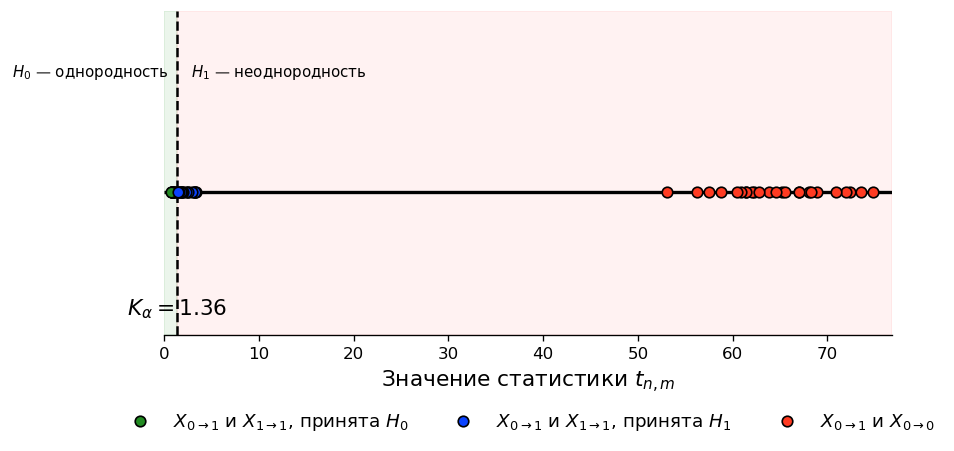

In [18]:
ks_anom_def = np.array([
    1.65, 2.49, 3.09, 3.33, 3.29,
    3.20, 2.88, 2.50, 2.28, 2.00,
    1.90, 1.85, 1.72, 1.53, 1.41,
    1.31, 1.17, 1.03, 0.99, 0.84,
    0.79, 0.80, 0.80, 0.80, 0.68
])

ks_anom_nodef = np.array([
    61.40, 72.44, 62.21, 62.03, 63.85,
    65.22, 67.04, 61.43, 56.28, 60.88,
    68.11, 71.93, 74.84, 73.55, 70.92,
    68.86, 68.26, 67.03, 65.48, 64.54,
    62.74, 60.50, 58.80, 57.53, 53.10
])

k_alpha = 1.36
a = 4.0
b = 50.0
compress = 0.12  

def x_map(x):
    x = np.asarray(x, dtype=float)
    out = x.copy()
    gap = (b - a)
    out[x > b] = a + compress*gap + (x[x > b] - b)
    mid = (x > a) & (x <= b)
    out[mid] = a + compress*(x[mid] - a)
    return out
    
# x_def = x_map(ks_anom_def)
# x_nodef = x_map(ks_anom_nodef)
x_def = ks_anom_def
x_nodef = ks_anom_nodef

x_k = x_map(np.array([k_alpha]))[0]

mask_h0 = ks_anom_def < k_alpha
mask_h1 = ks_anom_def > k_alpha
x_left = 0
x_right = x_map(np.array([ks_anom_nodef.max()]))[0] + 2
x_right = x_nodef.max() + 2
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
ax.hlines(0, x_left, x_right, color='black', linewidth=2)
ax.axvline(x_k, color='black', linestyle='--', linewidth=1.5)
ax.text(x_k, -0.16, r'$K_{\alpha}=1.36$', ha='center', va='top', fontsize=13)
ax.text((x_left + x_k - 17)/2, 0.18, r'$H_0$ — однородность', ha='center', fontsize=9)
ax.text((x_k + x_right - 54)/2, 0.18, r'$H_1$ — неоднородность', ha='center', fontsize=9)
ax.axvspan(x_left, x_k, alpha=0.08, color='green')
ax.axvspan(x_k, x_right, alpha=0.05, color='red')
ax.scatter(x_def[mask_h0], np.zeros(mask_h0.sum()), s=40,
           color='forestgreen', edgecolor='black', zorder=3,
           label=r'$X_{0\to1}$ и $X_{1\to1}$, принята $H_0$')
ax.scatter(x_def[mask_h1], np.zeros(mask_h1.sum()), s=40,
           color='#0b43ff', edgecolor='black', zorder=3,
           label=r'$X_{0\to1}$ и $X_{1\to1}$, принята $H_1$')
ax.scatter(x_nodef, np.zeros(len(x_nodef)), s=40,
           color='#ff3b22', edgecolor='black', zorder=3,
           label=r'$X_{0\to1}$ и $X_{0\to0}$')
ax.set_xlim(x_left, x_right)
ax.set_ylim(-0.22, 0.28)
ax.set_yticks([])
ax.set_xlabel(r'Значение статистики $t_{n,m}$', fontsize=13)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(False)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
jpeg( fig, 'ks_test_H0_H1', path_ch2_graphics  )

# Сильная корреляция соседних признаков, стр. 28-31

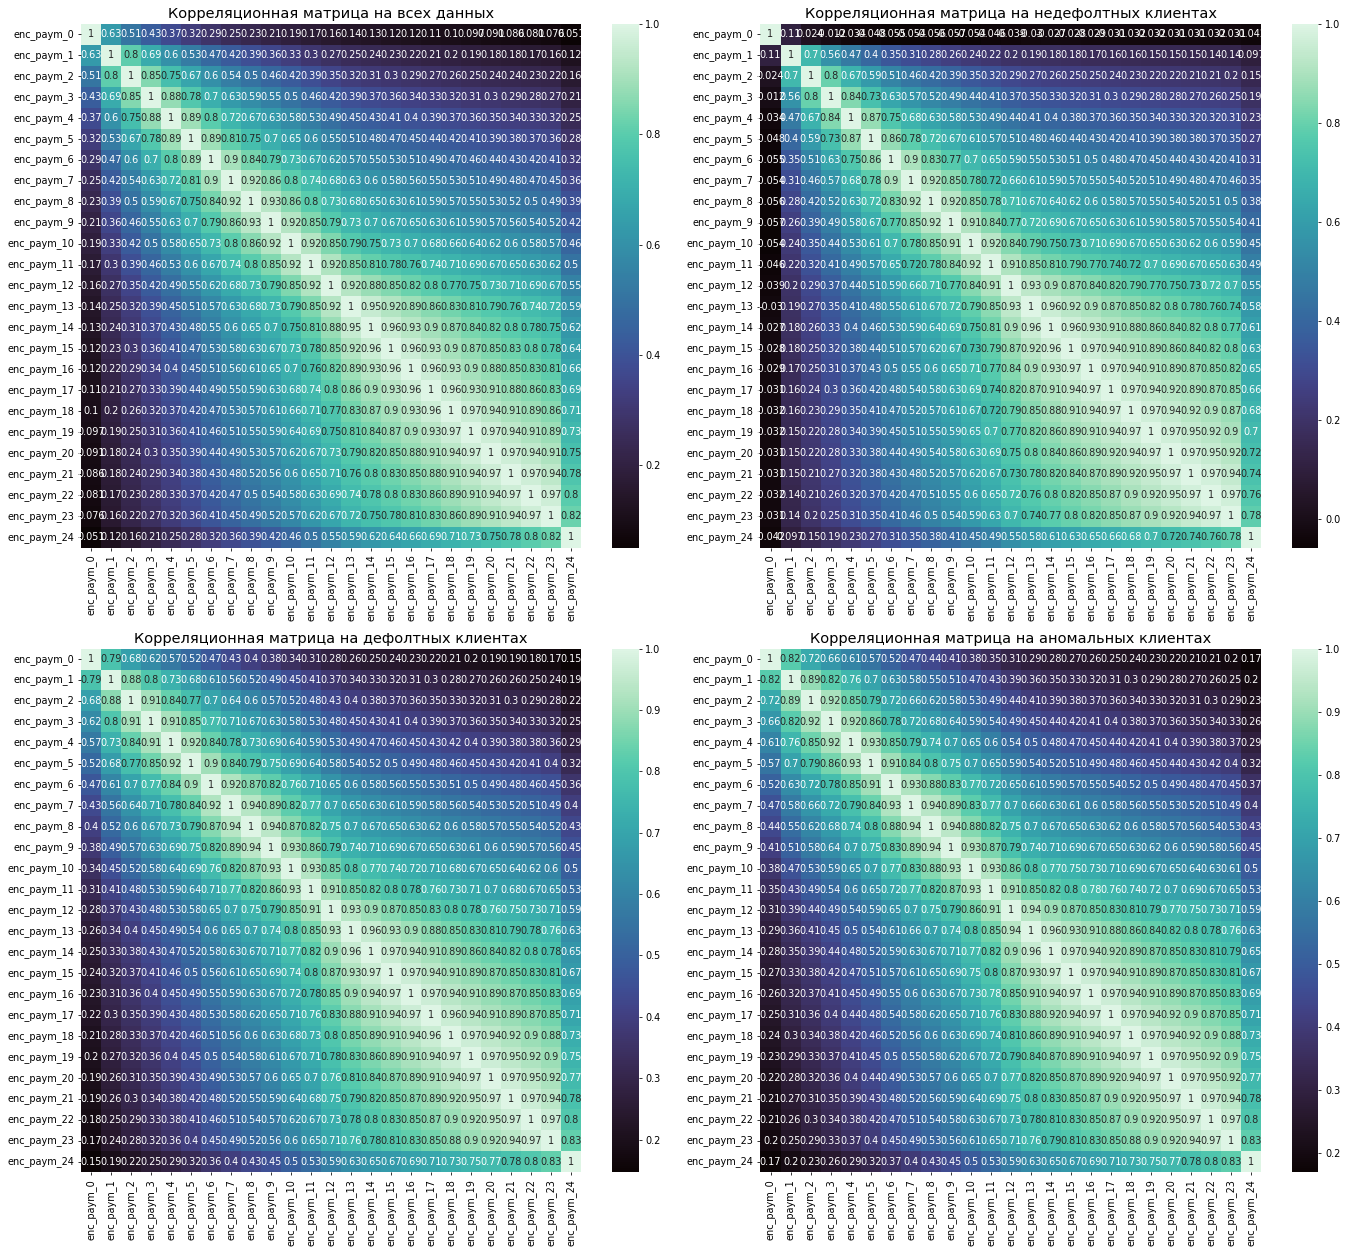

In [19]:
fig, ax = plt.subplots( nrows=2,
                        ncols=2,
                        figsize = (20, 18),
                        dpi = 70)

ax = ax.flatten() # превращаем в одномер-й плоский массив ax, чтобы обращаться по индексу ax[i], а не ax[0,0] 

sns.heatmap( df_all_25.loc[:, columns_pay_25].corr(), annot=True, ax=ax[0], cmap="mako" )
ax[0].set_title('Корреляционная матрица на всех данных', fontsize=15)

sns.heatmap( df_all_25.loc[np.where(y_==0)[0], columns_pay_25].corr(), annot=True, ax=ax[1], cmap="mako" )
ax[1].set_title('Корреляционная матрица на недефолтных клиентах', fontsize=15)

sns.heatmap( df_all_25.loc[np.where(y_==1)[0], columns_pay_25].corr(), annot=True, ax=ax[2], cmap="mako" )
ax[2].set_title('Корреляционная матрица на дефолтных клиентах', fontsize=15)

sns.heatmap( df_all_25.loc[ ind_anom, columns_pay_25].corr(), annot=True, ax=ax[3], cmap="mako")
ax[3].set_title('Корреляционная матрица на аномальных клиентах', fontsize=15)

plt.tight_layout()
jpeg(fig, 'cmap', path_ch2_graphics)

In [20]:
col1 =  X_pay_25.enc_paym_24
col2 =  X_pay_25.enc_paym_23
print( 'all_c:',np.corrcoef( col1, col2  )[0,1] )
print( 'nod_c:',np.corrcoef( col1[y_==0], col2[y_==0]  )[0,1] )
print( 'def_c:',np.corrcoef( col1[y_==1], col2[y_==1]  )[0,1] )
print( 'ano_c:',np.corrcoef( col1[ind_anom], col2[ind_anom]  )[0,1] )

all_c: 0.7920360734066937
nod_c: 0.7812612965133797
def_c: 0.8305650463993722
ano_c: 0.8307870801412942


# Изменение корреляции между соседними признаками, стр. 29

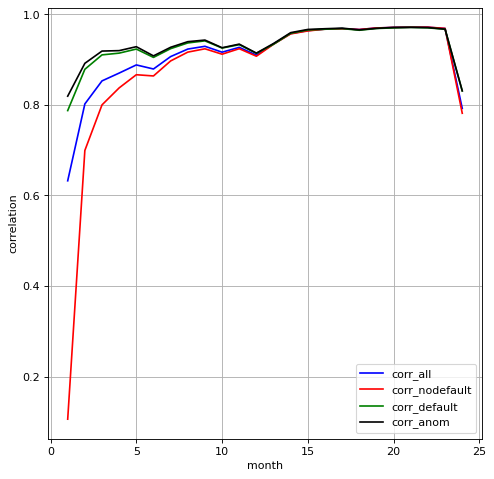

In [21]:
all_c, nod_c, def_c, ano_c, an2_c = [], [], [], [], []
month = []
for i in range( 1, X_pay_25.shape[1] ):
    all_c.append( np.corrcoef( np.array(X_pay_25).T[i-1], np.array(X_pay_25).T[i] )[0,1] )
    ind_nod = np.where(y_==0)[0]
    nod_c.append( np.corrcoef( np.array(X_pay_25).T[i-1][ind_nod], np.array(X_pay_25).T[i][ind_nod] )[0,1] )
    ind_def = np.where(y==1)[0]
    def_c.append( np.corrcoef( np.array(X_pay_25).T[i-1][ind_def], np.array(X_pay_25).T[i][ind_def] )[0,1] )
    ind_ano = ind_anom
    ano_c.append( np.corrcoef( np.array(X_pay_25).T[i-1][ind_ano], np.array(X_pay_25).T[i][ind_ano] )[0,1] )  
    month.append(i)
fig, (ax) = plt.subplots( figsize = (7, 7),
                          dpi = 80)
ax.plot( month, all_c, color = 'blue', label = 'corr_all' )
ax.plot( month, nod_c, color = 'red',  label = 'corr_nodefault' )
ax.plot( month, def_c, color = 'green',label = 'corr_default' )
ax.plot( month, ano_c, color = 'black',label = 'corr_anom' )
#ax.plot( month, an2_c, color = 'pink',label = 'corr_anom2' )
ax.grid()
ax.legend()
ax.set_xlabel('month')
ax.set_ylabel('correlation')
jpeg(fig, 'group_corr', path_ch2_graphics)

# Тест Фишера за 25 месяцев, стр.29

In [22]:
def transform_f( r, R, n ):    
    if n > 3:
        return 0.5*np.log( ((1+r)/(1-r))*((1-R)/(1+R)) )*np.sqrt(n-3)
    else:
        return 0
transform_f( r11, r11, n11 ), transform_f( r00, 0.99, n00 )

(0.0, -1.4377597808479745)

In [23]:
mth = 23
n_all, n_nod, n_def, n_ano = X_pay_25.shape[0], len(ind_nod), len(ind_def), len(ind_ano) 
R_all, r_nod, r_def, r_ano = all_c[mth], nod_c[mth], def_c[mth], ano_c[mth]
transform_f( r_nod, R_all, n_nod  ), transform_f( r_def, R_all, n_def  ), transform_f( r_ano, R_all, n_ano  )

(-22.361001661541376, 69.19717696402185, 66.41398402820266)

# Глава 2. Базовые алгоритмы оценки вероятности возврата кредита

# Тестирование алгоритмов на 19 признаках без подбора гиперпараметров на 1 млн клиентов

In [4]:
columns_pay_19 = ['enc_paym_0', 'enc_paym_1', 'enc_paym_2',
                  'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 
                  'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 
                  'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 
                  'enc_paym_12', 'enc_paym_13', 'enc_paym_14', 
                  'enc_paym_15', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24']
X_pay_19 = df_all_25.loc[:1000000, columns_pay_19].copy()

In [5]:
df_y = pd.read_csv('train_target.csv')
y  = df_y.flag.values[:1000001]
y_ = df_y.flag.values[:1000001] 

In [ ]:
# c = np.cov(X_pay_19).T
# np.linalg.eigen(c)[1]

In [6]:
pca = PCA()  
pca.fit(X_pay_19)  
100*pca.explained_variance_ratio_.round(3)

array([65.5, 14.9,  6. ,  3.3,  2.2,  1.6,  1.1,  0.9,  0.8,  0.7,  0.6,
        0.5,  0.4,  0.4,  0.3,  0.3,  0.3,  0.2,  0.1])

# Аномальные клиенты (25 признаков)

In [7]:
counter_norm, counter_anom = 0, 0
ind_norm, ind_anom = [], []
for i,x_pay in enumerate(np.array(X_pay_25)):
    if y_[i]==0 and min(x_pay)>0:
        counter_anom +=1
        ind_anom.append( i )
        y_[i]=1
    else:
        counter_norm +=1
        ind_norm.append( i )
        
print(f'amount of anomal customer={counter_anom}')
print(f'amount of normal customer={counter_norm}') 

amount of anomal customer=340594
amount of normal customer=659407


# Разбиение на тренировочную и тестовую выборки

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split( X_pay_19, y_, test_size = 0.25, random_state = 0  )

# Алгоритм Decision Tree - 1 млн, стр. 32-34

In [9]:
dtree = DecisionTreeClassifier()
dtree.fit( X_train, Y_train ) 
dtree.score( X_train, Y_train ), dtree.score( X_test, Y_test )

(0.992876, 0.967876128495486)

# Метрики точности

In [10]:
y_pred_train = dtree.predict( X_train )
y_proba_train = dtree.predict_proba( X_train )
y_pred_test = dtree.predict( X_test )
y_proba_test = dtree.predict_proba( X_test )

print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    469239
           1       1.00      0.98      0.99    280761

    accuracy                           0.99    750000
   macro avg       0.99      0.99      0.99    750000
weighted avg       0.99      0.99      0.99    750000

              precision    recall  f1-score   support

           0       0.97      0.98      0.97    156325
           1       0.96      0.95      0.96     93676

    accuracy                           0.97    250001
   macro avg       0.97      0.96      0.97    250001
weighted avg       0.97      0.97      0.97    250001



# Метрика ROC-AUC

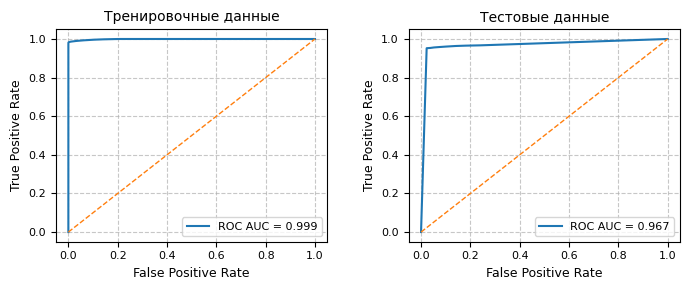

In [11]:
y_score_train = dtree.predict_proba(X_train)[:, 1]   
y_score_test = dtree.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_DT_train_test', path_ch2_graphics)

# Матрица ошибок

[[469203     36]
 [  5307 275454]]
[[152768   3557]
 [  4474  89202]]


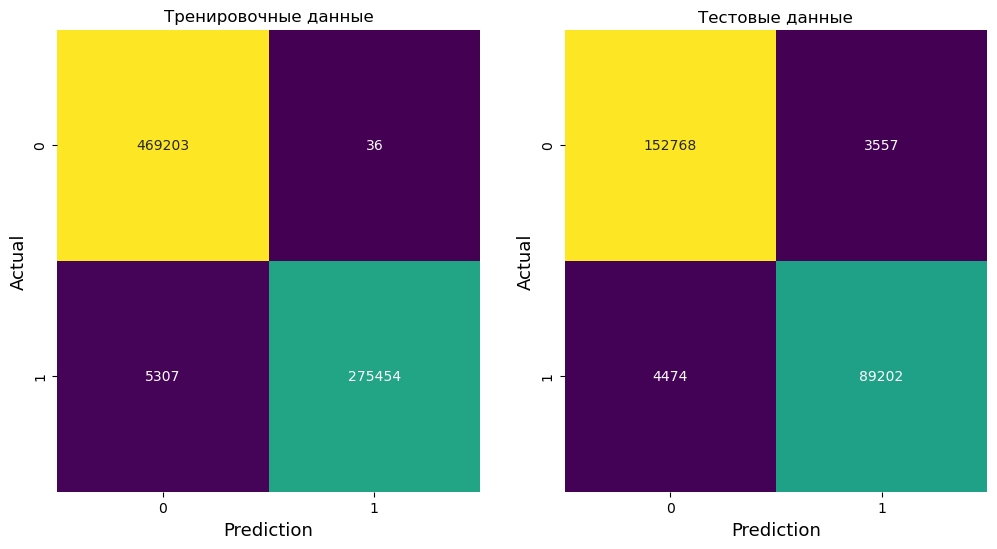

In [12]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = dtree.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = dtree.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')

plt.show()
jpeg(fig, 'matrix_dtr_train_test', path_ch2_graphics)

# Алгоритм Random Forest - 1 млн, стр. 34-35

In [13]:
rfc = RandomForestClassifier( )
rfc.fit( X_train, Y_train )
rfc.score( X_train, Y_train ), rfc.score( X_test, Y_test)

(0.992848, 0.9807440770236919)

# Метрики точности

In [14]:
y_pred_train = rfc.predict( X_train )
y_pred_test = rfc.predict( X_test )
y_proba_train = rfc.predict_proba( X_train )
y_proba_test = rfc.predict_proba( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    469239
           1       1.00      0.98      0.99    280761

    accuracy                           0.99    750000
   macro avg       0.99      0.99      0.99    750000
weighted avg       0.99      0.99      0.99    750000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    156325
           1       1.00      0.95      0.97     93676

    accuracy                           0.98    250001
   macro avg       0.98      0.97      0.98    250001
weighted avg       0.98      0.98      0.98    250001



# Метрика ROC-AUC

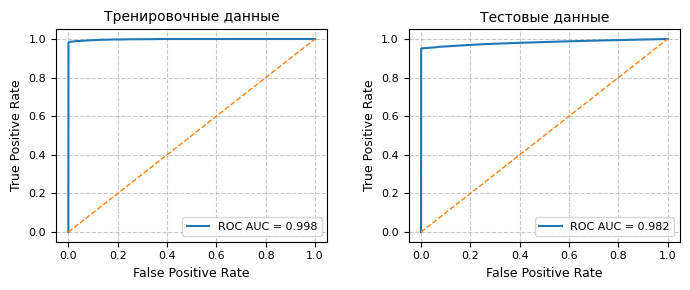

In [15]:
y_score_train = rfc.predict_proba(X_train)[:, 1]   
y_score_test = rfc.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_RF_train_test', path_ch2_graphics)

# Матрица ошибок

[[469166     73]
 [  5291 275470]]
[[156121    204]
 [  4610  89066]]


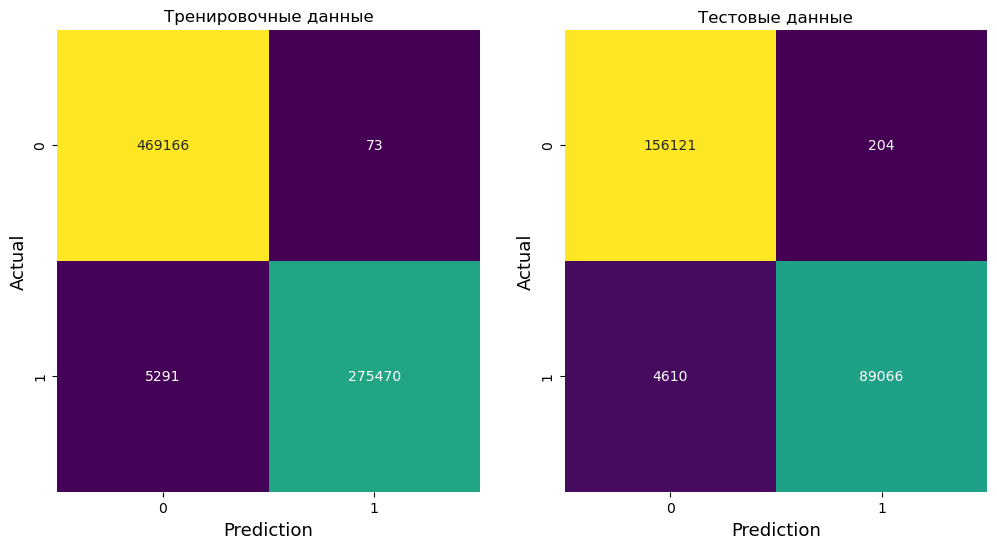

In [16]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = rfc.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = rfc.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')

plt.show()
jpeg(fig, 'matrix_rfc_train_test', path_ch2_graphics)

# Алгоритм Gradient Boosting - 1 млн, стр. 36-37

In [17]:
boost_gr = GradientBoostingClassifier()
boost_gr.fit(X_train, Y_train)
boost_gr.score( X_train, Y_train ), boost_gr.score( X_test, Y_test )

(0.978576, 0.97812408750365)

# Метрики точности 

In [18]:
y_pred_train = boost_gr.predict( X_train )
y_proba_train = boost_gr.predict_proba( X_train )
y_pred_test = boost_gr.predict( X_test )
y_proba_test = boost_gr.predict_proba( X_test )

print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    469239
           1       0.99      0.95      0.97    280761

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.98    750000
weighted avg       0.98      0.98      0.98    750000

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    156325
           1       0.99      0.95      0.97     93676

    accuracy                           0.98    250001
   macro avg       0.98      0.97      0.98    250001
weighted avg       0.98      0.98      0.98    250001



# Метрика ROC-AUC

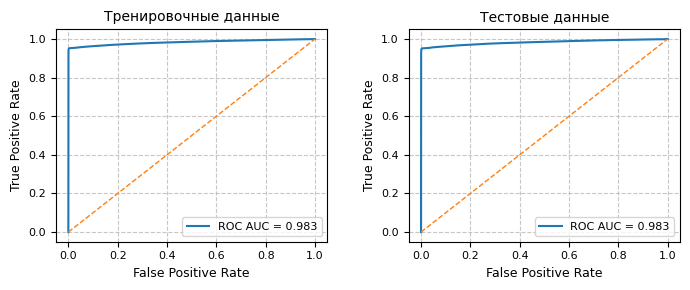

In [19]:
y_score_train = boost_gr.predict_proba(X_train)[:, 1]   
y_score_test = boost_gr.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_GRB_train_test', path_ch2_graphics)

# Матрица ошибок

[[466566   2673]
 [ 13395 267366]]
[[155413    912]
 [  4557  89119]]


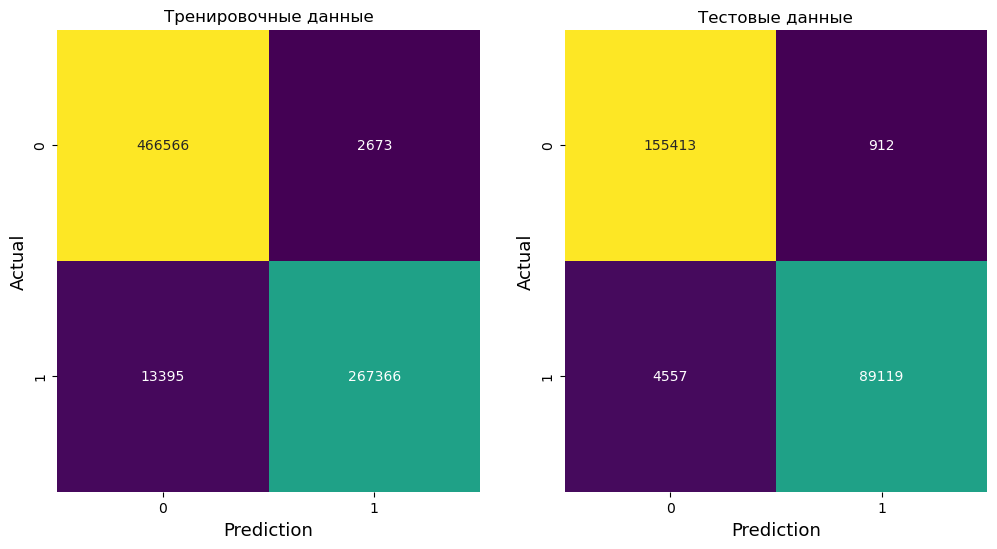

In [20]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = boost_gr.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = boost_gr.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')

plt.show()
jpeg(fig, 'matrix_grb_train_test', path_ch2_graphics)

# Нейронная сеть - 1 млн, стр. 37-39

![График](neural_network.png)
*Рисунок 1 – Архитектура нейронной сети*

# Стандартизация данных

In [73]:
# from sklearn.preprocessing import MinMaxScaler, StandardScaler
# scaler = MinMaxScaler()
# #scaler = StandardScaler()
# X_train_, X_test_ = scaler.fit_transform(X_train), scaler.fit_transform(X_test)

In [21]:
epochs = 20 # указывает на количество раз, когда модель пересматривает весь набор данных
model = keras.Sequential()            
model.add(keras.Input(shape=(19,)))  
model.add(Dense(32, activation='relu'))   
model.add(keras.layers.Dense(1, activation='sigmoid')) 
opt = keras.optimizers.Adam(learning_rate=0.005)
metrics = keras.metrics.BinaryAccuracy(name="accuracy", dtype=None, threshold=0.5)
model.compile(optimizer=opt, loss='mse', metrics=metrics)
fit_history = model.fit(X_train, Y_train, 
                        batch_size = 128, # количество обучающих примеров в пакете, в каждом пакете содержится 128 обучающих примеров
                        # 1 954 партий в каждом из 128 пакетов
                        validation_data = (X_test, Y_test),
                        epochs = epochs)
model.save("my_model_1mln.h5")

2026-04-27 10:22:29.049052: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 10:22:30.100680: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


Epoch 1/20
5860/5860 [==============================] - 5s 807us/step - loss: 0.0650 - accuracy: 0.9188 - val_loss: 0.0264 - val_accuracy: 0.9711
Epoch 2/20
5860/5860 [==============================] - 4s 639us/step - loss: 0.0256 - accuracy: 0.9722 - val_loss: 0.0235 - val_accuracy: 0.9751
Epoch 3/20
5860/5860 [==============================] - 4s 627us/step - loss: 0.0237 - accuracy: 0.9747 - val_loss: 0.0218 - val_accuracy: 0.9769
Epoch 4/20
5860/5860 [==============================] - 3s 597us/step - loss: 0.0219 - accuracy: 0.9770 - val_loss: 0.0223 - val_accuracy: 0.9760
Epoch 5/20
5860/5860 [==============================] - 4s 637us/step - loss: 0.0210 - accuracy: 0.9780 - val_loss: 0.0209 - val_accuracy: 0.9784
Epoch 6/20
5860/5860 [==============================] - 4s 599us/step - loss: 0.0204 - accuracy: 0.9789 - val_loss: 0.0206 - val_accuracy: 0.9788
Epoch 7/20
5860/5860 [==============================] - 4s 611us/step - loss: 0.0229 - accuracy: 0.9762 - val_loss: 0.0243 -

In [22]:
model = keras.models.load_model("my_model_1mln.h5")

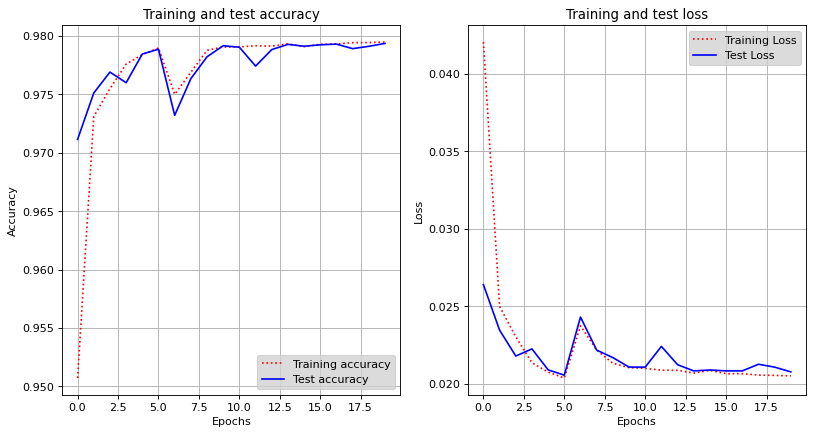

In [23]:
acc = fit_history.history['accuracy']
val_acc = fit_history.history['val_accuracy']
loss = fit_history.history['loss']
val_loss = fit_history.history['val_loss']
epochs = range(len(acc))

fig, ( ax1, ax2 ) = plt.subplots( nrows=1, 
                                  ncols=2,
                                  dpi= 80,
                                  figsize=(12,6))
ax1.plot(epochs, acc, 'r:', label='Training accuracy')
ax1.plot(epochs, val_acc, 'b', label='Test accuracy')
ax1.set_title('Training and test accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.grid(True)
ax1.legend(facecolor="lightgrey")

ax2.plot(epochs, loss, 'r:', label='Training Loss')
ax2.plot(epochs, val_loss, 'b', label='Test Loss')
ax2.set_title('Training and test loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.grid(True)
ax2.legend(facecolor="lightgrey")

In [24]:
proba_train = model.predict(X_train)
proba_test = model.predict(X_test)

In [25]:
col1_train = proba_train.T[0]
y_proba_train = np.array([1-col1_train,col1_train]).T
y_pred_train = np.zeros(len(col1_train)).astype(int) 
y_pred_train[col1_train>0.5] = 1
col1_test = proba_test.T[0]
y_proba_test = np.array([1-col1_test,col1_test]).T
y_pred_test = np.zeros(len(col1_test)).astype(int) 
y_pred_test[col1_test>0.5] = 1

# Метрики точности

In [26]:
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    469239
           1       0.99      0.95      0.97    280761

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.98    750000
weighted avg       0.98      0.98      0.98    750000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    156325
           1       0.99      0.95      0.97     93676

    accuracy                           0.98    250001
   macro avg       0.98      0.97      0.98    250001
weighted avg       0.98      0.98      0.98    250001



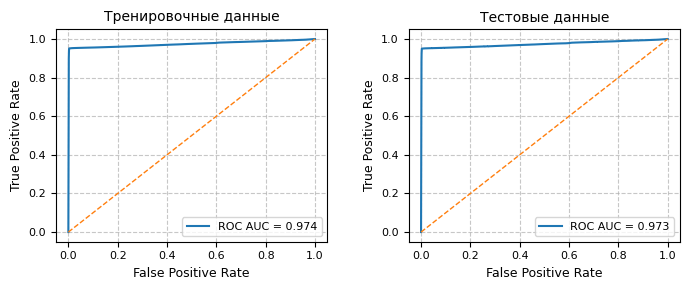

In [27]:
y_score = proba_train[:,0]
fpr, tpr, thr = roc_curve(Y_train, y_score)
auc = roc_auc_score(Y_train, y_score)

fig, (ax1, ax2) = plt.subplots( nrows=1, 
                               ncols=2, 
                               figsize=(7, 3), 
                               dpi=100)

ax1.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax1.plot([0, 1], [0, 1], '--', linewidth=1) 
ax1.set_xlabel('False Positive Rate', fontsize=9)
ax1.set_ylabel('True Positive Rate', fontsize=9)
ax1.set_title('Тренировочные данные', fontsize=10)
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.tick_params(axis='both', which='major', labelsize=8)

y_score =  proba_test[:,0]
fpr, tpr, thr = roc_curve(Y_test, y_score)
auc = roc_auc_score(Y_test, y_score)

ax2.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], '--', linewidth=1) 
ax2.set_xlabel('False Positive Rate', fontsize=9)
ax2.set_ylabel('True Positive Rate', fontsize=9)
ax2.set_title('Тестовые данные', fontsize=10)
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_nn_train_test', path_ch2_graphics)

# Матрица ошибок

[[467806   1433]
 [ 13695 267066]]
[[155828    497]
 [  4670  89006]]


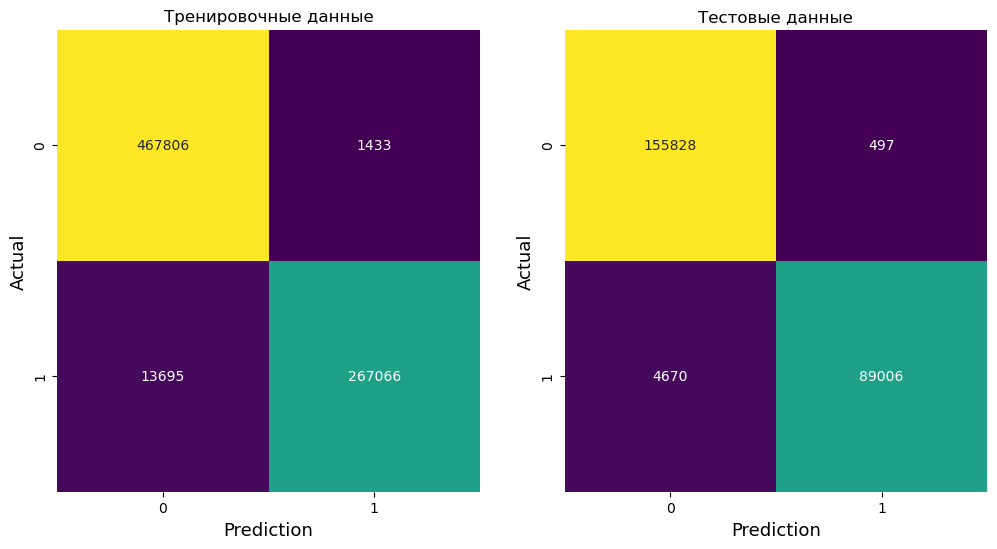

In [28]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )
                                             
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            
sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_xlabel('Prediction',fontsize = 13)                                           
ax1.set_ylabel('Actual',fontsize = 13) 
ax1.set_title('Тренировочные данные')
                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_xlabel('Prediction',fontsize = 13)                                           
ax2.set_ylabel('Actual',fontsize = 13)
ax2.set_title('Тестовые данные')
jpeg(fig, 'matrix_nn_train_test', path_ch2_graphics)

# Глава 3. Тестирование алгоритмов машинного и глубокого обучения на больших данных по кредитному скорингу, стр. 40

# Подбор гиперпараметров для алгоритмов машинного обучения при оценке возврата кредита, стр. 40

# Загрузка данных - 3 миллиона

In [4]:
file_csv_all_19 = '2_data_csv_all_19.csv'
df_19 = pd.read_csv(file_csv_all_19).loc[:,:]
columns_pay_19 = ['enc_paym_0', 'enc_paym_1', 'enc_paym_2',
                  'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 
                  'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 
                  'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 
                  'enc_paym_12', 'enc_paym_13', 'enc_paym_14', 
                  'enc_paym_15', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24']
X_pay_19 = df_all_25.loc[:, columns_pay_19].copy() # для экономии ОП
X_pay_25 = df_all_25.loc[:, columns_pay_25].copy()

In [5]:
df_y = pd.read_csv('train_target.csv')
y_ = df_y.flag.values[:]        # Глава 3. 3 млн клиентов
y  = df_y.flag.values[:]        # Глава 3. 3 млн клиентов

In [10]:
y[y==0].shape[0]

2893558

In [11]:
976052/2893558

0.33731896855013793

# Выявление аномальных клиентов (0 --> 1). Глава 3. 3 млн клиентов

In [6]:
counter_norm, counter_anom = 0, 0
ind_norm, ind_anom = [], []
for i,x_pay in enumerate(np.array(X_pay_25)):
    if y_[i]==0 and min(x_pay)>0:
        counter_anom +=1
        ind_anom.append( i )
        y_[i]=1
    else:
        counter_norm +=1
        ind_norm.append( i )
print(f'amount of anomal customer={counter_anom}')
print(f'amount of normal customer={counter_norm}') 

amount of anomal customer=976052
amount of normal customer=2023948


In [10]:
976052/3000000

0.3253506666666667

# Разбиение на тренировочную и тестовую выборки

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split( X_pay_19, y_, test_size=0.25, random_state=0 )

# Алгоритм Decision Tree - 3 млн, стр. 41-44

# Результаты подбора гиперпараметров с помощью GridSearchCV, стр. 43

In [8]:
dtree = DecisionTreeClassifier(criterion='entropy', 
                               max_depth=20, 
                               max_features='log2',
                               min_samples_leaf=15, 
                               min_samples_split=15,
                               random_state=42)
dtree.fit( X_train, Y_train ) 
dtree.score( X_train, Y_train ), dtree.score( X_test, Y_test )

(0.9787817777777778, 0.978636)

# Метрики точности

In [9]:
y_pred_train = dtree.predict( X_train )
y_proba_train = dtree.predict_proba( X_train )
y_pred_test = dtree.predict( X_test )
y_proba_test = dtree.predict_proba( X_test )

y_pred_test = dtree.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98   1438790
           1       1.00      0.94      0.97    811210

    accuracy                           0.98   2250000
   macro avg       0.98      0.97      0.98   2250000
weighted avg       0.98      0.98      0.98   2250000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    478716
           1       1.00      0.94      0.97    271284

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.98    750000
weighted avg       0.98      0.98      0.98    750000



# Метрика ROC-AUC

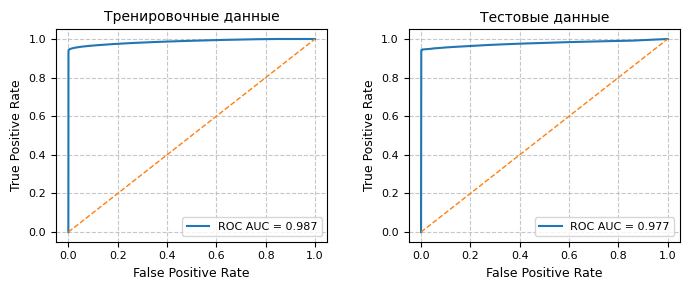

In [10]:
y_score_train = dtree.predict_proba(X_train)[:, 1]   
y_score_test = dtree.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_DT_train_test_3mln_grid', path_ch3_graphics)

# Матрица ошибок

[[1436337    2453]
 [  45288  765922]]
[[477800    916]
 [ 15107 256177]]


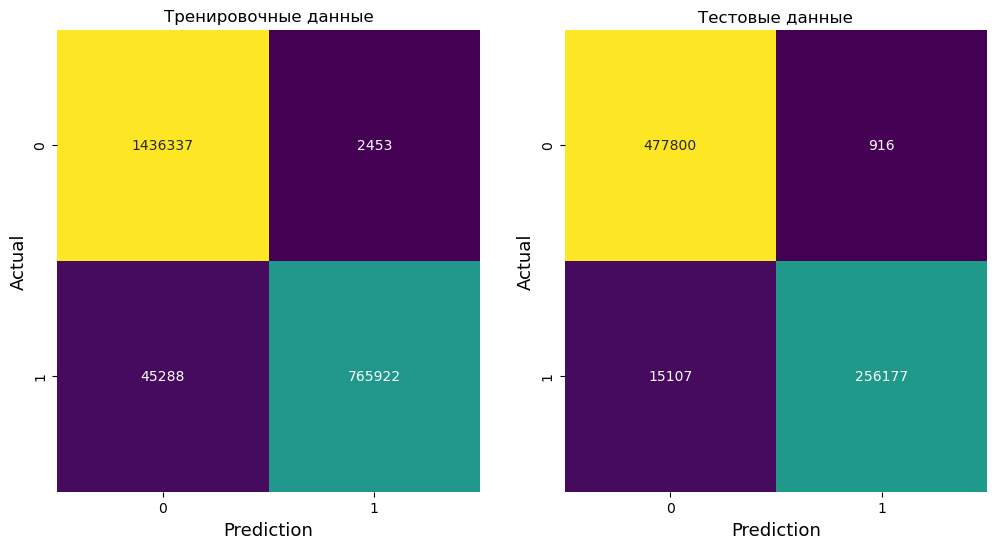

In [11]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = dtree.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = dtree.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')
plt.show()
jpeg(fig, 'matrix_dtr_train_test_3mln_grid', path_ch3_graphics)

# Результаты подбора гиперпараметров с помощью RandomSearchCV, стр. 44

In [12]:
dtree = DecisionTreeClassifier(criterion='entropy', 
                               max_depth=25, 
                               max_features='log2',
                               min_samples_leaf=10, 
                               min_samples_split=10,
                               random_state=42)
dtree.fit( X_train, Y_train ) 
dtree.score( X_train, Y_train ), dtree.score( X_test, Y_test )

(0.979228, 0.9789853333333334)

# Метрики точности

In [13]:
y_pred_train = dtree.predict( X_train )
y_proba_train = dtree.predict_proba( X_train )
y_pred_test = dtree.predict( X_test )
y_proba_test = dtree.predict_proba( X_test )

y_pred_test = dtree.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98   1438790
           1       1.00      0.94      0.97    811210

    accuracy                           0.98   2250000
   macro avg       0.98      0.97      0.98   2250000
weighted avg       0.98      0.98      0.98   2250000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    478716
           1       1.00      0.94      0.97    271284

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.98    750000
weighted avg       0.98      0.98      0.98    750000



# Метрика ROC-AUC

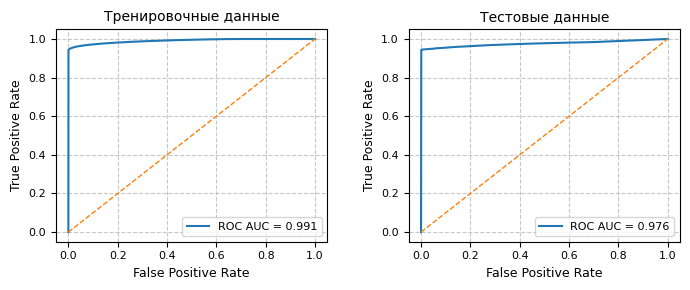

In [14]:
y_score_train = dtree.predict_proba(X_train)[:, 1]   
y_score_test = dtree.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_DT_train_test_3mln_random', path_ch3_graphics)

# Матрица ошибок

[[1437245    1545]
 [  45192  766018]]
[[478035    681]
 [ 15080 256204]]


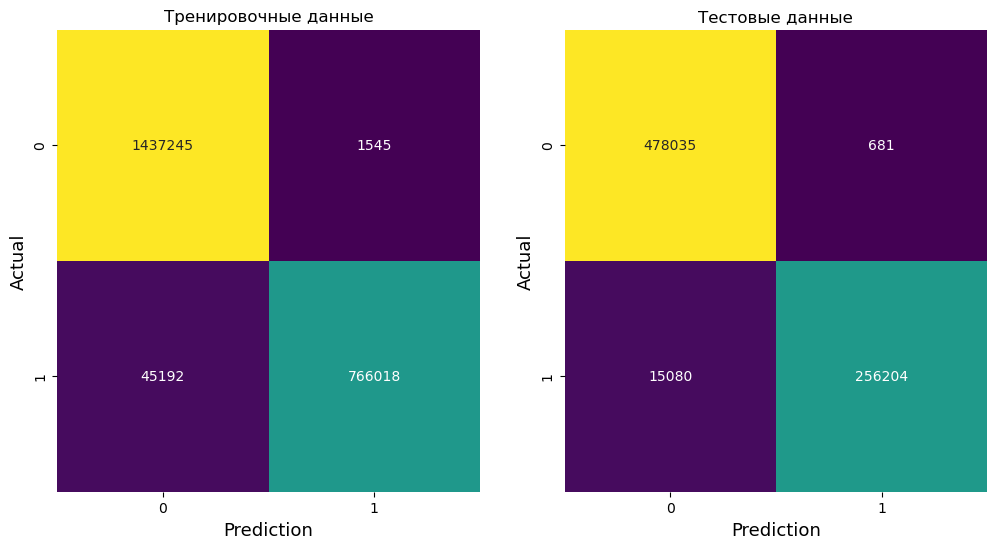

In [15]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = dtree.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = dtree.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')

plt.show()
jpeg(fig, 'matrix_dtr_train_test_3mln_random', path_ch3_graphics)

# Запись Decision Tree в формат pkl для деплоя в Streamlit

In [16]:
with open('dtree.pkl', 'wb') as file:
    pickle.dump( dtree, file, protocol=pickle.HIGHEST_PROTOCOL)

# Алгоритм Random Forest - 3 млн, стр. 44-47

# Результаты подбора гиперпараметров с помощью Gridsearch, стр. 45-46

In [17]:
rfc = RandomForestClassifier(max_depth=20, 
                             min_samples_leaf=10, 
                             min_samples_split=30,
                             n_estimators=60, 
                             random_state=42)
rfc.fit( X_train, Y_train )
rfc.score( X_train, Y_train ), rfc.score( X_test, Y_test )

(0.9798884444444445, 0.9799693333333334)

# Метрики точности

In [18]:
y_pred_train = rfc.predict( X_train )
y_proba_train = rfc.predict_proba( X_train )
y_pred_test = rfc.predict( X_test )
y_proba_test = rfc.predict_proba( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98   1438790
           1       1.00      0.94      0.97    811210

    accuracy                           0.98   2250000
   macro avg       0.98      0.97      0.98   2250000
weighted avg       0.98      0.98      0.98   2250000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    478716
           1       1.00      0.95      0.97    271284

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.98    750000
weighted avg       0.98      0.98      0.98    750000



# Метрика ROC-AUC

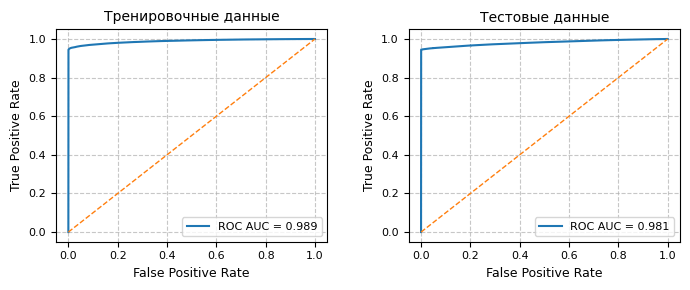

In [19]:
y_score_train = rfc.predict_proba(X_train)[:, 1]   
y_score_test = rfc.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_RFC_train_test_3mln_grid', path_ch3_graphics)

# Матрица ошибок

[[1438482     308]
 [  44943  766267]]
[[478607    109]
 [ 14914 256370]]


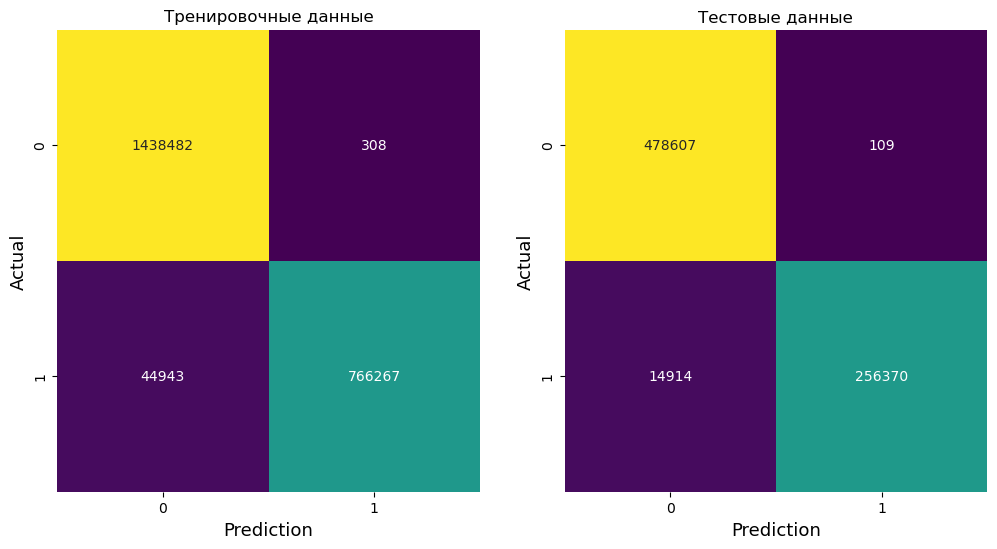

In [20]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = rfc.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = rfc.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')
plt.show()
jpeg(fig, 'matrix_rfc_train_test_3mln_grid', path_ch3_graphics)

# Запись Random Forest в формат pkl для деплоя в Streamlit

In [21]:
with open('rfc.pkl', 'wb') as file:
    pickle.dump( rfc, file, protocol=pickle.HIGHEST_PROTOCOL)

# Результаты подбора гиперпараметров с помощью RandomSearchCV, стр. 46-47

In [22]:
rfc = RandomForestClassifier(criterion='entropy', 
                             max_depth=30, 
                             min_samples_leaf=10,
                             min_samples_split=10,
                             max_features='log2',
                             n_estimators=40, 
                             random_state=42)
rfc.fit( X_train, Y_train )
rfc.score( X_train, Y_train ), rfc.score( X_test, Y_test )

(0.9798831111111111, 0.979928)

# Метрики точности

In [23]:
y_pred_train = rfc.predict( X_train )
y_proba_train = rfc.predict_proba( X_train )
y_pred_test = rfc.predict( X_test )
y_proba_test = rfc.predict_proba( X_test )

y_pred_test = rfc.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98   1438790
           1       1.00      0.94      0.97    811210

    accuracy                           0.98   2250000
   macro avg       0.98      0.97      0.98   2250000
weighted avg       0.98      0.98      0.98   2250000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    478716
           1       1.00      0.94      0.97    271284

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.98    750000
weighted avg       0.98      0.98      0.98    750000



# Метрика ROC-AUC

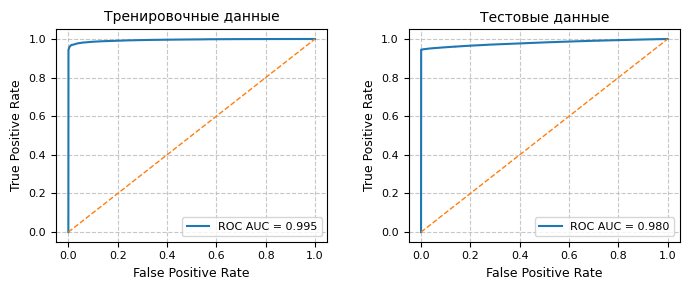

In [24]:
y_score_train = rfc.predict_proba(X_train)[:, 1]   
y_score_test = rfc.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_RFC_train_test_random', path_ch3_graphics)

# Матрица ошибок

[[1438461     329]
 [  44934  766276]]
[[478583    133]
 [ 14921 256363]]


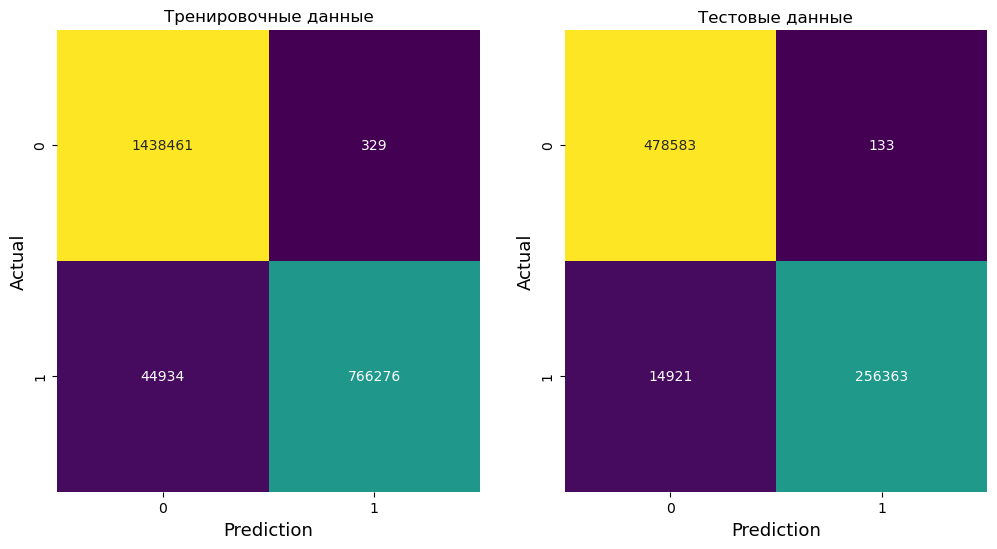

In [25]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = rfc.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = rfc.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')
plt.show()
jpeg(fig, 'matrix_rfc_train_test_3mln_random', path_ch3_graphics)

# Алгоритм Gradient Boosting - 3 млн, 47-48

In [26]:
boost_gr = GradientBoostingClassifier()
boost_gr.fit(X_train, Y_train)
boost_gr.score( X_train, Y_train ), boost_gr.score( X_test, Y_test )

(0.9768177777777778, 0.9768773333333334)

# Метрики точности

In [27]:
y_pred_train = boost_gr.predict( X_train )
y_proba_train = boost_gr.predict_proba( X_train )
y_pred_test = boost_gr.predict( X_test )
y_proba_test = boost_gr.predict_proba( X_test )

y_pred_test = boost_gr.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      0.99      0.98   1438790
           1       0.99      0.95      0.97    811210

    accuracy                           0.98   2250000
   macro avg       0.98      0.97      0.97   2250000
weighted avg       0.98      0.98      0.98   2250000

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    478716
           1       0.99      0.95      0.97    271284

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.97    750000
weighted avg       0.98      0.98      0.98    750000



# Метрика ROC-AUC

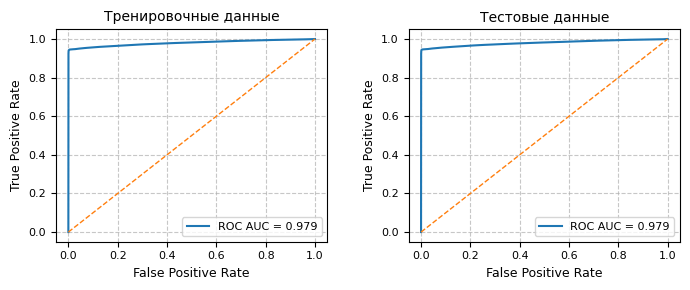

In [28]:
y_score_train = boost_gr.predict_proba(X_train)[:, 1]   
y_score_test = boost_gr.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_BOOST_train_test_3mln', path_ch3_graphics)

# Матрица ошибок

[[1431082    7708]
 [  44452  766758]]
[[476119   2597]
 [ 14745 256539]]


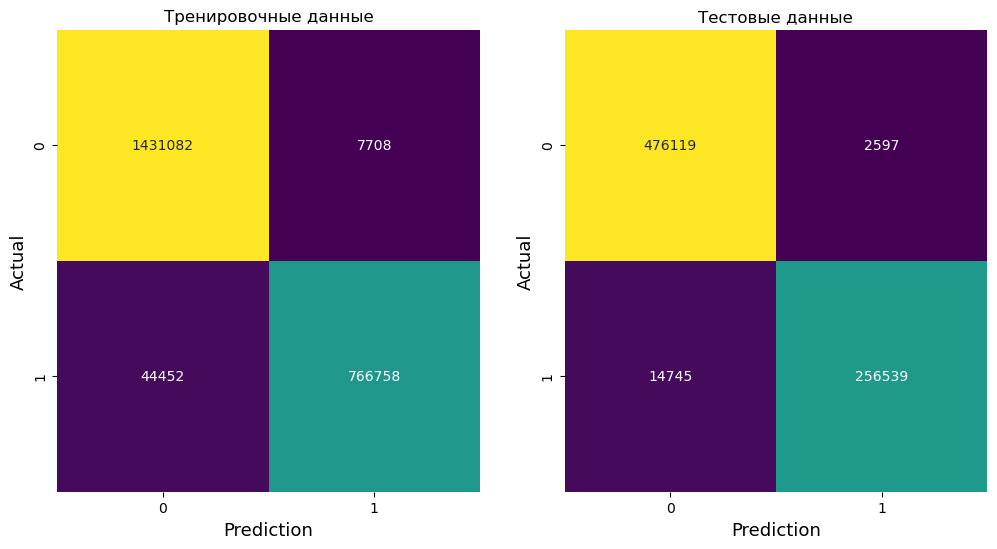

In [29]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = boost_gr.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = boost_gr.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')
jpeg(fig, 'matrix_boost_train_test_3mln_', path_ch3_graphics)

# Запись Gradient Boosting в формат pkl для деплоя в Streamlit

In [30]:
with open('boost_gr.pkl', 'wb') as file:
    pickle.dump( boost_gr, file, protocol=pickle.HIGHEST_PROTOCOL)

# Neural Network - 3 млн, стр. 48-51

In [31]:
epochs = 20 # указывает на количество раз, когда модель пересматривает весь набор данных

model = keras.Sequential()            
model.add(keras.Input(shape=(19,)))  
model.add(Dense(32, activation='relu'))
model.add(keras.layers.Dense(1, activation='sigmoid')) 

opt = keras.optimizers.Adam(learning_rate=0.005)
metrics = keras.metrics.BinaryAccuracy(name="accuracy", dtype=None, threshold=0.5)

model.compile(optimizer=opt, loss='mse', metrics=metrics)
fit_history = model.fit(X_train, Y_train, 
                        batch_size = 128, # количество обучающих примеров в пакете, в каждом пакете содержится 128 обучающих примеров
                        # 1 954 партий в каждом из 128 пакетов
                        validation_data = (X_test, Y_test),
                        epochs = epochs)

model.save("my_model_3mln.h5")

2026-04-27 11:37:57.421194: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 11:37:57.914860: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


Epoch 1/20
17579/17579 [==============================] - 13s 699us/step - loss: 0.0461 - accuracy: 0.9451 - val_loss: 0.0228 - val_accuracy: 0.9763
Epoch 2/20
17579/17579 [==============================] - 11s 619us/step - loss: 0.0229 - accuracy: 0.9762 - val_loss: 0.0214 - val_accuracy: 0.9779
Epoch 3/20
17579/17579 [==============================] - 11s 603us/step - loss: 0.0218 - accuracy: 0.9776 - val_loss: 0.0208 - val_accuracy: 0.9787
Epoch 4/20
17579/17579 [==============================] - 11s 635us/step - loss: 0.0221 - accuracy: 0.9774 - val_loss: 0.0227 - val_accuracy: 0.9764
Epoch 5/20
17579/17579 [==============================] - 12s 660us/step - loss: 0.0226 - accuracy: 0.9768 - val_loss: 0.0210 - val_accuracy: 0.9788
Epoch 6/20
17579/17579 [==============================] - 11s 647us/step - loss: 0.0212 - accuracy: 0.9785 - val_loss: 0.0210 - val_accuracy: 0.9787
Epoch 7/20
17579/17579 [==============================] - 15s 872us/step - loss: 0.0210 - accuracy: 0.9786

In [32]:
model = keras.models.load_model("my_model_3mln.h5")

In [33]:
proba_train = model.predict(X_train)
proba_test = model.predict(X_test)

In [34]:
col1_train = proba_train.T[0]
y_proba_train = np.array([1-col1_train,col1_train]).T
y_pred_train = np.zeros(len(col1_train)).astype(int) 
y_pred_train[col1_train>0.5] = 1
col1_test = proba_test.T[0]
y_proba_test = np.array([1-col1_test,col1_test]).T
y_pred_test = np.zeros(len(col1_test)).astype(int) 
y_pred_test[col1_test>0.5] = 1

# Метрики точности

In [35]:
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98   1438790
           1       1.00      0.94      0.97    811210

    accuracy                           0.98   2250000
   macro avg       0.98      0.97      0.98   2250000
weighted avg       0.98      0.98      0.98   2250000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    478716
           1       1.00      0.94      0.97    271284

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.98    750000
weighted avg       0.98      0.98      0.98    750000



# Метрика ROC-AUC

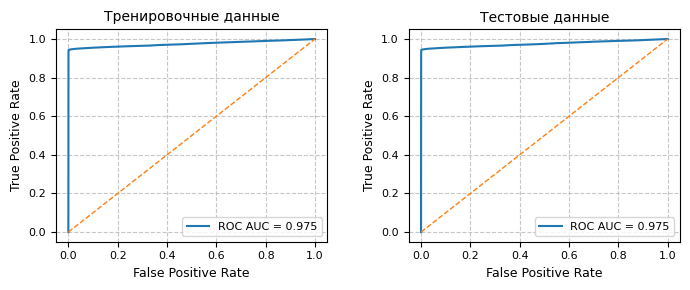

In [36]:
y_score = proba_train[:,0]
fpr, tpr, thr = roc_curve(Y_train, y_score)
auc = roc_auc_score(Y_train, y_score)

fig, (ax1, ax2) = plt.subplots( nrows=1, 
                               ncols=2, 
                               figsize=(7, 3), 
                               dpi=100)

ax1.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax1.plot([0, 1], [0, 1], '--', linewidth=1) 
ax1.set_xlabel('False Positive Rate', fontsize=9)
ax1.set_ylabel('True Positive Rate', fontsize=9)
ax1.set_title('Тренировочные данные', fontsize=10)
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.tick_params(axis='both', which='major', labelsize=8)

y_score =  proba_test[:,0]
fpr, tpr, thr = roc_curve(Y_test, y_score)
auc = roc_auc_score(Y_test, y_score)

ax2.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], '--', linewidth=1) 
ax2.set_xlabel('False Positive Rate', fontsize=9)
ax2.set_ylabel('True Positive Rate', fontsize=9)
ax2.set_title('Тестовые данные', fontsize=10)
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
jpeg(fig, 'ROC_AUC_nn_train_test_3mln', path_ch3_graphics)

# Результаты обучения нейронной сети на тренировочной и тестовой выборках, стр. 50

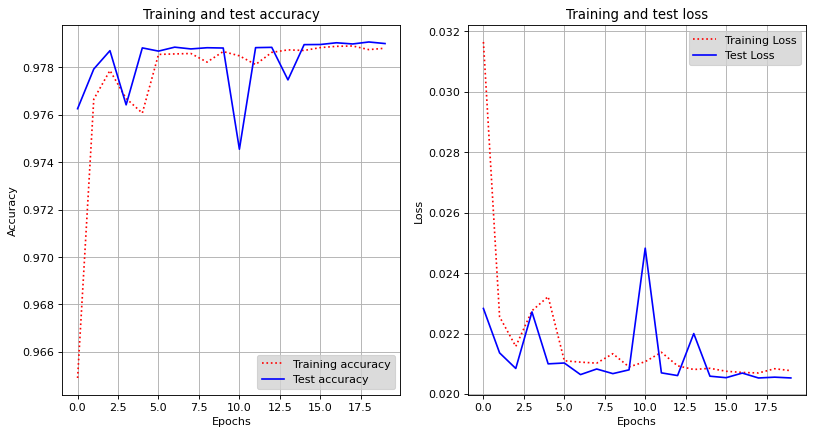

In [37]:
acc = fit_history.history['accuracy']
val_acc = fit_history.history['val_accuracy']
loss = fit_history.history['loss']
val_loss = fit_history.history['val_loss']
epochs = range(len(acc))

fig, ( ax1, ax2 ) = plt.subplots( nrows=1, 
                                  ncols=2,
                                  dpi= 80,
                                  figsize=(12,6))
ax1.plot(epochs, acc, 'r:', label='Training accuracy')
ax1.plot(epochs, val_acc, 'b', label='Test accuracy')
ax1.set_title('Training and test accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.grid(True)
ax1.legend(facecolor="lightgrey")

ax2.plot(epochs, loss, 'r:', label='Training Loss')
ax2.plot(epochs, val_loss, 'b', label='Test Loss')
ax2.set_title('Training and test loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.grid(True)
ax2.legend(facecolor="lightgrey")
plt.show()
jpeg(fig, 'nn_accuracy_3mln', path_ch3_graphics)

# Матрица ошибок

[[1436727    2063]
 [  45301  765909]]
[[478023    693]
 [ 15054 256230]]


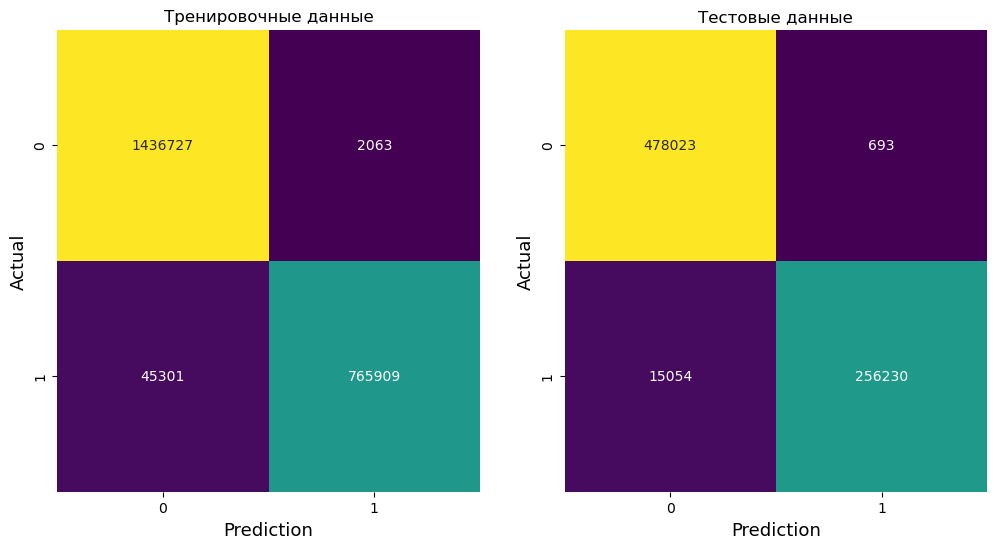

In [38]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )                                            
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            
sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_xlabel('Prediction',fontsize = 13)                                           
ax1.set_ylabel('Actual',fontsize = 13) 
ax1.set_title('Тренировочные данные')
                                            
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_xlabel('Prediction',fontsize = 13)                                           
ax2.set_ylabel('Actual',fontsize = 13)
ax2.set_title('Тестовые данные')
jpeg(fig, 'matrix_nn_train_test_3mln', path_ch3_graphics)